# EGX Volatility Forecasting

In [1]:
import os
import sys
import time
import math
import json


LOCAL_FIGS    = "/home/jovyan/work/figs"
LOCAL_RESULTS = "/home/jovyan/work/results"
os.makedirs(LOCAL_FIGS, exist_ok=True)
os.makedirs(LOCAL_RESULTS, exist_ok=True)

HDFS_BASE     = "hdfs://namenode:9000"
HDFS_CLEAN    = f"{HDFS_BASE}/egx/clean_panel.parquet"
HDFS_FEATURES = f"{HDFS_BASE}/egx/feature_panel.parquet"
HDFS_RESULTS  = f"{HDFS_BASE}/egx/results"

print(f"Python: {sys.version}")
print(f"Output figures -> {LOCAL_FIGS}")
print(f"Output results -> {LOCAL_RESULTS}")

Python: 3.11.6 | packaged by conda-forge | (main, Oct  3 2023, 10:40:35) [GCC 12.3.0]
Output figures -> /home/jovyan/work/figs
Output results -> /home/jovyan/work/results


In [2]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window

spark = (SparkSession.builder
    .appName("EGX_Models")
    .config("spark.driver.memory", "3g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "16")
    .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")


Spark version: 3.5.0


## Load Feature Panel and Train/Test Split


In [3]:
feats = spark.read.parquet(HDFS_FEATURES)
print(f"Feature panel: {feats.count():,} rows")

FEATURE_COLS = [
    "vol_5d", "vol_10d", "vol_20d", "vol_60d",
    "ret_1d", "ret_5d", "ret_20d", "abs_ret_1d",
    "volume_ratio",
    "parkinson_1d", "parkinson_20d",
    "usdegp_vol_20d", "brent_vol_20d", "eem_vol_20d",
    "sector_vol_20d",
    "dow", "month_end", "is_ramadan",
]
TARGET = "target_vol_5d_fwd"
SPLIT_DATE = "2024-01-01"

train_df = feats.filter(F.col("date") <  F.lit(SPLIT_DATE))
test_df  = feats.filter(F.col("date") >= F.lit(SPLIT_DATE))
print(f"\nTrain rows: {train_df.count():,}")
print(f"Test rows:  {test_df.count():,}")

Feature panel: 88,292 rows

Train rows: 73,901
Test rows:  14,391


---
## Naive Baseline

In [4]:
from pyspark.ml.evaluation import RegressionEvaluator

baseline_test = test_df.withColumn("prediction", F.col("vol_20d"))

evaluator_rmse = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="r2")

baseline_rmse = evaluator_rmse.evaluate(baseline_test)
baseline_mae  = evaluator_mae.evaluate(baseline_test)
baseline_r2   = evaluator_r2.evaluate(baseline_test)

print(f"Baseline (20-day persistence):")
print(f"  RMSE = {baseline_rmse:.6f}")
print(f"  MAE  = {baseline_mae:.6f}")
print(f"  R^2  = {baseline_r2:.4f}")

results = {"Baseline (20-day persistence)": {
    "rmse": baseline_rmse, "mae": baseline_mae, "r2": baseline_r2,
    "rmse_reduction_vs_baseline": 0.0
}}

Baseline (20-day persistence):
  RMSE = 0.019775
  MAE  = 0.011244
  R^2  = -0.2231


---
## Spark MLlib Models

In [5]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml import Pipeline

assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol="features")

def train_and_eval(model, name):
    print(f"Training: {name}")
    pipe = Pipeline(stages=[assembler, model])
    t0 = time.time()
    fitted = pipe.fit(train_df)
    train_time = time.time() - t0
    print(f"  Training time: {train_time:.1f}s")
    pred = fitted.transform(test_df)
    rmse = evaluator_rmse.evaluate(pred)
    mae  = evaluator_mae.evaluate(pred)
    r2   = evaluator_r2.evaluate(pred)
    reduction = 100 * (baseline_rmse - rmse) / baseline_rmse
    print(f"  RMSE = {rmse:.6f}  (vs baseline {baseline_rmse:.6f}, {reduction:+.1f}%)")
    print(f"  MAE  = {mae:.6f}")
    print(f"  R^2  = {r2:.4f}")
    results[name] = {"rmse": rmse, "mae": mae, "r2": r2,
                     "rmse_reduction_vs_baseline": reduction,
                     "train_time_sec": train_time}
    return fitted, pred

In [6]:
lr_model, lr_pred = train_and_eval(
    LinearRegression(labelCol=TARGET, featuresCol="features",
                     regParam=0.01, elasticNetParam=0.5, maxIter=100),
    "Linear Regression")

Training: Linear Regression
  Training time: 2.3s
  RMSE = 0.018043  (vs baseline 0.019775, +8.8%)
  MAE  = 0.010904
  R^2  = -0.0183


In [7]:
rf_model, rf_pred = train_and_eval(
    RandomForestRegressor(labelCol=TARGET, featuresCol="features",
                          numTrees=100, maxDepth=8, seed=42),
    "Random Forest")

Training: Random Forest
  Training time: 4.9s
  RMSE = 0.017325  (vs baseline 0.019775, +12.4%)
  MAE  = 0.009760
  R^2  = 0.0612


In [8]:
gbt_model, gbt_pred = train_and_eval(
    GBTRegressor(labelCol=TARGET, featuresCol="features",
                 maxIter=80,          
                 maxDepth=3,           
                 stepSize=0.05,        
                 subsamplingRate=0.8,  
                 seed=42),
    "Gradient-Boosted Trees")

Training: Gradient-Boosted Trees
  Training time: 9.8s
  RMSE = 0.016726  (vs baseline 0.019775, +15.4%)
  MAE  = 0.009698
  R^2  = 0.1251


### Feature Importances (Random Forest)

       feature  importance
    is_ramadan    0.001844
           dow    0.015046
        ret_1d    0.015494
     month_end    0.016367
  volume_ratio    0.021400
    abs_ret_1d    0.040593
   eem_vol_20d    0.043955
usdegp_vol_20d    0.044420
        ret_5d    0.046500
       ret_20d    0.048201
  parkinson_1d    0.051927
       vol_60d    0.068444
 parkinson_20d    0.077414
       vol_10d    0.084168
        vol_5d    0.086217
 brent_vol_20d    0.101021
sector_vol_20d    0.115437
       vol_20d    0.121552


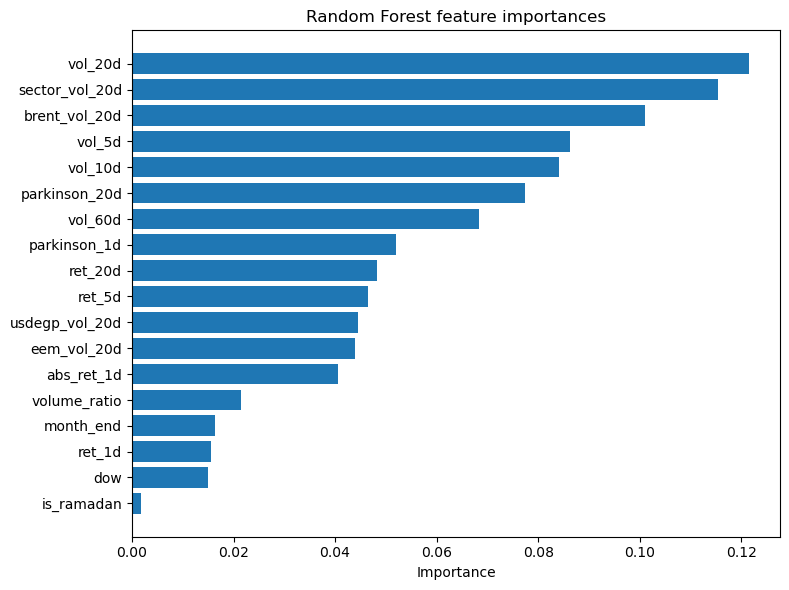

In [9]:
rf_inner = rf_model.stages[-1]
importances = rf_inner.featureImportances.toArray()
import pandas as pd
imp_df = (pd.DataFrame({"feature": FEATURE_COLS, "importance": importances})
            .sort_values("importance", ascending=True))
print(imp_df.to_string(index=False))

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.barh(imp_df["feature"], imp_df["importance"])
plt.xlabel("Importance")
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.savefig(f"{LOCAL_FIGS}/fig_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## PyTorch LSTM 

In [10]:
pdf = feats.select("ticker", "sector", "date",
                   *FEATURE_COLS, TARGET).toPandas()
pdf["date"] = pd.to_datetime(pdf["date"])
pdf = pdf.sort_values(["ticker", "date"]).reset_index(drop=True)
print(f"Loaded {len(pdf):,} rows for LSTM preparation")

Loaded 88,292 rows for LSTM preparation


In [11]:
import numpy as np

SEQ_LEN = 60

train_mask = pdf["date"] <  pd.Timestamp(SPLIT_DATE)
val_mask   = (pdf["date"] >= pd.Timestamp("2023-01-01")) & (pdf["date"] <  pd.Timestamp(SPLIT_DATE))
test_mask  = pdf["date"] >= pd.Timestamp(SPLIT_DATE)
train_only = train_mask & ~val_mask

mu     = pdf.loc[train_only, FEATURE_COLS].mean()
sigma_norm = pdf.loc[train_only, FEATURE_COLS].std().replace(0, 1)
pdf[FEATURE_COLS] = (pdf[FEATURE_COLS] - mu) / sigma_norm


In [12]:
def build_sequences(df_subset):
    Xs, ys, tickers, dates = [], [], [], []
    for ticker, group in df_subset.groupby("ticker", sort=False):
        g = group.reset_index(drop=True)
        if len(g) < SEQ_LEN:
            continue
        feat_arr = g[FEATURE_COLS].to_numpy(dtype=np.float32)
        targ_arr = g[TARGET].to_numpy(dtype=np.float32)
        for i in range(SEQ_LEN - 1, len(g)):
            Xs.append(feat_arr[i - SEQ_LEN + 1: i + 1])
            ys.append(targ_arr[i])
            tickers.append(ticker)
            dates.append(g.loc[i, "date"])
    return (np.stack(Xs), np.array(ys, dtype=np.float32),
            np.array(tickers), np.array(dates))

print("building sequences")
X_tr, y_tr, _, _    = build_sequences(pdf[train_only])
X_val, y_val, _, _  = build_sequences(pdf[val_mask])
X_te, y_te, te_tk, te_dt = build_sequences(pdf[test_mask | val_mask])
te_keep = pd.Series(te_dt) >= pd.Timestamp(SPLIT_DATE)
X_te, y_te, te_tk, te_dt = X_te[te_keep], y_te[te_keep], te_tk[te_keep], te_dt[te_keep]

print(f"  X_train: {X_tr.shape}, y_train: {y_tr.shape}")
print(f"  X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"  X_test:  {X_te.shape}, y_test:  {y_te.shape}")

building sequences
  X_train: (65819, 60, 18), y_train: (65819,)
  X_val:   (4188, 60, 18), y_val:   (4188,)
  X_test:  (14391, 60, 18), y_test:  (14391,)


In [13]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [14]:
class VolLSTM(nn.Module):
    def __init__(self, n_features, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)

In [15]:
torch.manual_seed(42)
model = VolLSTM(n_features=len(FEATURE_COLS)).to(DEVICE)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

Trainable parameters: 56,897


In [16]:
def to_tensor_dataset(X, y):
    return TensorDataset(torch.from_numpy(X), torch.from_numpy(y))

train_loader = DataLoader(to_tensor_dataset(X_tr, y_tr), batch_size=256, shuffle=True)
val_loader   = DataLoader(to_tensor_dataset(X_val, y_val), batch_size=512, shuffle=False)
test_loader  = DataLoader(to_tensor_dataset(X_te, y_te), batch_size=512, shuffle=False)


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


def evaluate(loader):
    model.eval()
    losses, preds, trues = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            p = model(xb)
            losses.append(loss_fn(p, yb).item() * len(yb))
            preds.append(p.cpu().numpy())
            trues.append(yb.cpu().numpy())
    n = sum(len(t) for t in trues)
    rmse = math.sqrt(sum(losses) / n)
    return rmse, np.concatenate(preds), np.concatenate(trues)


In [17]:
EPOCHS, PATIENCE = 30, 5
best_val, patience_left, best_state = float("inf"), PATIENCE, None
history = []
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item() * len(yb))
    train_rmse = math.sqrt(sum(train_losses) / len(train_loader.dataset))
    val_rmse, _, _ = evaluate(val_loader)
    history.append({"epoch": epoch, "train_rmse": train_rmse, "val_rmse": val_rmse})
    print(f"Epoch {epoch:2d}  train RMSE={train_rmse:.6f}  val RMSE={val_rmse:.6f}")
    if val_rmse < best_val - 1e-6:
        best_val, best_state, patience_left = val_rmse, {k: v.clone() for k,v in model.state_dict().items()}, PATIENCE
    else:
        patience_left -= 1
        if patience_left == 0:
            print(f"  Early stopping at epoch {epoch} (best val RMSE = {best_val:.6f})")
            break
lstm_train_time = time.time() - t0
print(f"\nLSTM total training time: {lstm_train_time:.1f}s")
if best_state is not None:
    model.load_state_dict(best_state)

Epoch  1  train RMSE=0.030937  val RMSE=0.014898
Epoch  2  train RMSE=0.026205  val RMSE=0.014846
Epoch  3  train RMSE=0.025561  val RMSE=0.014869
Epoch  4  train RMSE=0.024937  val RMSE=0.014776
Epoch  5  train RMSE=0.024721  val RMSE=0.014752
Epoch  6  train RMSE=0.024664  val RMSE=0.014784
Epoch  7  train RMSE=0.024500  val RMSE=0.014709
Epoch  8  train RMSE=0.023869  val RMSE=0.014739
Epoch  9  train RMSE=0.024393  val RMSE=0.014599
Epoch 10  train RMSE=0.021191  val RMSE=0.014816
Epoch 11  train RMSE=0.024901  val RMSE=0.014914
Epoch 12  train RMSE=0.024755  val RMSE=0.015572
Epoch 13  train RMSE=0.020747  val RMSE=0.014817
Epoch 14  train RMSE=0.017967  val RMSE=0.014940
  Early stopping at epoch 14 (best val RMSE = 0.014599)

LSTM total training time: 158.5s


In [18]:
lstm_rmse, lstm_preds, lstm_trues = evaluate(test_loader)
lstm_mae = float(np.mean(np.abs(lstm_preds - lstm_trues)))
ss_res = float(np.sum((lstm_trues - lstm_preds) ** 2))
ss_tot = float(np.sum((lstm_trues - lstm_trues.mean()) ** 2))
lstm_r2 = 1.0 - ss_res / ss_tot
reduction = 100 * (baseline_rmse - lstm_rmse) / baseline_rmse
print(f"LSTM:  RMSE = {lstm_rmse:.6f}  ({reduction:+.1f}% vs baseline)")
print(f"       MAE  = {lstm_mae:.6f}")
print(f"       R^2  = {lstm_r2:.4f}")

results["LSTM"] = {"rmse": lstm_rmse, "mae": lstm_mae, "r2": lstm_r2,
                   "rmse_reduction_vs_baseline": reduction,
                   "train_time_sec": lstm_train_time}

lstm_test_pdf = pd.DataFrame({"ticker": te_tk, "date": te_dt,
                              "y_true": lstm_trues, "y_pred": lstm_preds})
lstm_test_pdf.to_csv(f"{LOCAL_RESULTS}/lstm_test_predictions.csv", index=False)

LSTM:  RMSE = 0.016170  (+18.2% vs baseline)
       MAE  = 0.009583
       R^2  = 0.1822


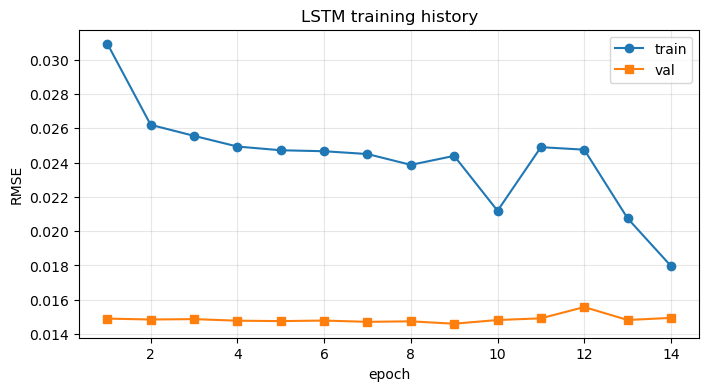

In [19]:
# Training history plot
hist_df = pd.DataFrame(history)
plt.figure(figsize=(8, 4))
plt.plot(hist_df["epoch"], hist_df["train_rmse"], label="train", marker="o")
plt.plot(hist_df["epoch"], hist_df["val_rmse"], label="val", marker="s")
plt.xlabel("epoch"); plt.ylabel("RMSE"); plt.title("LSTM training history")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{LOCAL_FIGS}/fig_lstm_training.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Final Comparison Table

In [20]:
comp = pd.DataFrame(results).T
keep_cols = ["rmse", "mae", "r2", "rmse_reduction_vs_baseline"]
comp = comp[[c for c in keep_cols if c in comp.columns]]
comp.columns = ["RMSE", "MAE", "R²", "RMSE Reduction vs. Baseline (%)"]
comp = comp.round({"RMSE": 6, "MAE": 6, "R²": 4, "RMSE Reduction vs. Baseline (%)": 1})
print(comp.to_string())
comp.to_csv(f"{LOCAL_RESULTS}/table_model_comparison.csv")

                                   RMSE       MAE      R²  RMSE Reduction vs. Baseline (%)
Baseline (20-day persistence)  0.019775  0.011244 -0.2231                              0.0
Linear Regression              0.018043  0.010904 -0.0183                              8.8
Random Forest                  0.017325  0.009760  0.0612                             12.4
Gradient-Boosted Trees         0.016726  0.009698  0.1251                             15.4
LSTM                           0.016170  0.009583  0.1822                             18.2


In [21]:
gbt_pdf_check = gbt_pred.select("date", "ticker", TARGET, "prediction").toPandas()
print("Prediction stats:")
print(gbt_pdf_check["prediction"].describe())
print("\nActual stats:")
print(gbt_pdf_check[TARGET].describe())
print("\nTop 5 wildest predictions:")
print(gbt_pdf_check.nlargest(5, "prediction"))
print("\nTop 5 most negative predictions:")
print(gbt_pdf_check.nsmallest(5, "prediction"))

Prediction stats:
count    14391.000000
mean         0.020939
std          0.009350
min          0.004455
25%          0.014706
50%          0.018736
75%          0.024466
max          0.145010
Name: prediction, dtype: float64

Actual stats:
count    14391.000000
mean         0.022431
std          0.017882
min          0.000406
25%          0.011935
50%          0.018295
75%          0.027763
max          0.598172
Name: target_vol_5d_fwd, dtype: float64

Top 5 wildest predictions:
            date ticker  target_vol_5d_fwd  prediction
7015  2024-03-11   OCDI           0.080377    0.145010
7891  2024-03-19   TMGH           0.026163    0.144459
478   2024-03-20   EFIH           0.093778    0.143631
477   2024-03-19   EFIH           0.073811    0.143029
7016  2024-03-12   OCDI           0.116478    0.142148

Top 5 most negative predictions:
             date ticker  target_vol_5d_fwd  prediction
9234   2024-05-29   MFPC           0.041810    0.004455
7926   2024-05-29   TMGH           0.0

---
## Per-Sector Error Breakdown

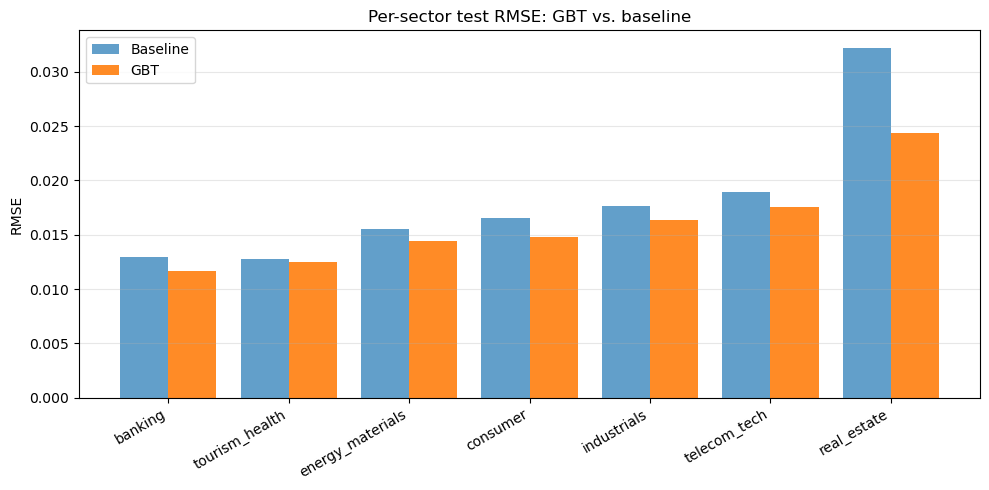

          sector  gbt_rmse  baseline_rmse  reduction_%
         banking  0.011631       0.012955    10.219306
  tourism_health  0.012466       0.012796     2.573216
energy_materials  0.014464       0.015560     7.043953
        consumer  0.014777       0.016530    10.605883
     industrials  0.016346       0.017631     7.287066
    telecom_tech  0.017558       0.018943     7.313210
     real_estate  0.024406       0.032206    24.220554


In [22]:
gbt_pdf = (gbt_pred.select("ticker", "sector", "date", TARGET, "prediction").toPandas())
gbt_pdf["abs_err"] = (gbt_pdf[TARGET] - gbt_pdf["prediction"]).abs()
gbt_pdf["sq_err"]  = (gbt_pdf[TARGET] - gbt_pdf["prediction"]) ** 2

baseline_pdf = (baseline_test.select("ticker", "sector", "date", TARGET, "prediction")
                              .withColumnRenamed("prediction", "baseline_pred").toPandas())
baseline_pdf["baseline_sq_err"] = (baseline_pdf[TARGET] - baseline_pdf["baseline_pred"]) ** 2

merged = gbt_pdf.merge(
    baseline_pdf[["ticker", "date", "baseline_pred", "baseline_sq_err"]],
    on=["ticker", "date"], how="inner")

sector_compare = (merged.groupby("sector")
                  .agg(gbt_rmse=("sq_err", lambda s: math.sqrt(s.mean())),
                       baseline_rmse=("baseline_sq_err", lambda s: math.sqrt(s.mean())))
                  .reset_index()
                  .sort_values("gbt_rmse"))
sector_compare["reduction_%"] = 100 * (sector_compare["baseline_rmse"] - sector_compare["gbt_rmse"]) / sector_compare["baseline_rmse"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(sector_compare))
ax.bar(x - 0.2, sector_compare["baseline_rmse"], width=0.4, label="Baseline", alpha=0.7)
ax.bar(x + 0.2, sector_compare["gbt_rmse"], width=0.4, label="GBT", alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(sector_compare["sector"], rotation=30, ha="right")
ax.set_ylabel("RMSE"); ax.set_title("Per-sector test RMSE: GBT vs. baseline")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{LOCAL_FIGS}/fig_sector_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

print(sector_compare.to_string(index=False))
sector_compare.to_csv(f"{LOCAL_RESULTS}/table_sector_compare.csv", index=False)

---
## Event Window Analysis: 2024 EGP Devaluation

GBT      pre-deval RMSE = 0.026193
GBT      post-deval RMSE = 0.023822
LSTM     pre-deval RMSE = 0.024440
LSTM     post-deval RMSE = 0.018578
Baseline pre-deval RMSE = 0.026077
Baseline post-deval RMSE = 0.020881


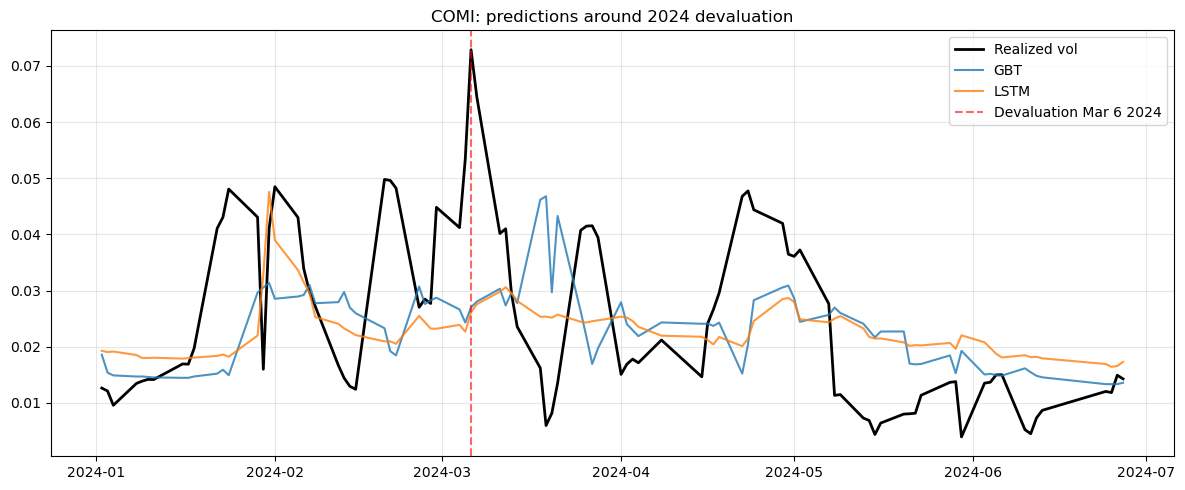

In [23]:
import matplotlib.dates as mdates

DEVAL_DATE = pd.Timestamp("2024-03-06")
WINDOW = 30
before = (DEVAL_DATE - pd.Timedelta(days=WINDOW), DEVAL_DATE - pd.Timedelta(days=1))
after  = (DEVAL_DATE, DEVAL_DATE + pd.Timedelta(days=WINDOW))

def window_rmse(df, true_col, pred_col, dates):
    sub = df[(df["date"] >= dates[0]) & (df["date"] <= dates[1])]
    if len(sub) == 0: return float("nan")
    return math.sqrt(((sub[true_col] - sub[pred_col]) ** 2).mean())

gbt_pdf["date"] = pd.to_datetime(gbt_pdf["date"])
lstm_test_pdf["date"] = pd.to_datetime(lstm_test_pdf["date"])
baseline_pdf["date"] = pd.to_datetime(baseline_pdf["date"])

print(f"GBT      pre-deval RMSE = {window_rmse(gbt_pdf, TARGET, 'prediction', before):.6f}")
print(f"GBT      post-deval RMSE = {window_rmse(gbt_pdf, TARGET, 'prediction', after):.6f}")
print(f"LSTM     pre-deval RMSE = {window_rmse(lstm_test_pdf, 'y_true', 'y_pred', before):.6f}")
print(f"LSTM     post-deval RMSE = {window_rmse(lstm_test_pdf, 'y_true', 'y_pred', after):.6f}")
print(f"Baseline pre-deval RMSE = {window_rmse(baseline_pdf, TARGET, 'baseline_pred', before):.6f}")
print(f"Baseline post-deval RMSE = {window_rmse(baseline_pdf, TARGET, 'baseline_pred', after):.6f}")

demo = "COMI"
p1 = gbt_pdf[(gbt_pdf["ticker"] == demo) & (gbt_pdf["date"] >= "2024-01-01") & (gbt_pdf["date"] <= "2024-06-30")].sort_values("date")
p2 = lstm_test_pdf[(lstm_test_pdf["ticker"] == demo) & (lstm_test_pdf["date"] >= "2024-01-01") & (lstm_test_pdf["date"] <= "2024-06-30")].sort_values("date")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p1["date"], p1[TARGET], "k-", label="Realized vol", linewidth=2)
ax.plot(p1["date"], p1["prediction"], label="GBT", alpha=0.8)
ax.plot(p2["date"], p2["y_pred"], label="LSTM", alpha=0.8)
ax.axvline(DEVAL_DATE, color="red", linestyle="--", alpha=0.6, label="Devaluation Mar 6 2024")
ax.set_title(f"{demo}: predictions around 2024 devaluation")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{LOCAL_FIGS}/fig_devaluation_event.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Forecast Visualization in Price Space

In [24]:
prices = (spark.read.parquet(HDFS_CLEAN)
           .filter(F.col("asset_class") == "equity")
           .select("ticker", "date", "price").toPandas())
prices["date"] = pd.to_datetime(prices["date"])
print(f"Loaded {len(prices):,} price observations")

Z80 = 1.2816
HISTORY_DAYS = 30

def project_cone(p0, sigma, n_days, z=Z80):
    k = np.arange(1, n_days + 1)
    factor = z * sigma * np.sqrt(k)
    return k, p0 * np.exp(-factor), p0 * np.exp(+factor)

Loaded 113,772 price observations


In [25]:
gbt_residuals  = (gbt_pdf[TARGET] - gbt_pdf["prediction"]).values
lstm_residuals = (lstm_test_pdf["y_true"] - lstm_test_pdf["y_pred"]).values
gbt_q10, gbt_q90  = np.percentile(gbt_residuals, [10, 90])
lstm_q10, lstm_q90 = np.percentile(lstm_residuals, [10, 90])
print(f"GBT q10={gbt_q10:+.5f} q90={gbt_q90:+.5f}")
print(f"LSTM q10={lstm_q10:+.5f} q90={lstm_q90:+.5f}")

combined = gbt_pdf[["ticker", "sector", "date", TARGET, "prediction"]].rename(
    columns={"prediction": "gbt_pred"}).merge(
    lstm_test_pdf[["ticker", "date", "y_pred"]].rename(columns={"y_pred": "lstm_pred"}),
    on=["ticker", "date"], how="inner")
combined["gbt_lo"]  = (combined["gbt_pred"]  + gbt_q10).clip(lower=0)
combined["gbt_hi"]  =  combined["gbt_pred"]  + gbt_q90
combined["lstm_lo"] = (combined["lstm_pred"] + lstm_q10).clip(lower=0)
combined["lstm_hi"] =  combined["lstm_pred"] + lstm_q90
combined["gbt_inside"]  = (combined[TARGET] >= combined["gbt_lo"])  & (combined[TARGET] <= combined["gbt_hi"])
combined["lstm_inside"] = (combined[TARGET] >= combined["lstm_lo"]) & (combined[TARGET] <= combined["lstm_hi"])
combined.to_csv(f"{LOCAL_RESULTS}/table_predictions_with_intervals.csv", index=False)
print(f"\nOverall coverage:  GBT {combined['gbt_inside'].mean()*100:.1f}%  LSTM {combined['lstm_inside'].mean()*100:.1f}%  (target 80%)")

GBT q10=-0.01151 q90=+0.01717
LSTM q10=-0.01195 q90=+0.01659

Overall coverage:  GBT 80.0%  LSTM 80.0%  (target 80%)


In [26]:
FORECAST_START = pd.Timestamp("2026-05-01")
FORECAST_END   = pd.Timestamp("2026-05-05")
PLOT_START     = pd.Timestamp("2026-04-01")
DEMO_TICKERS = ["COMI", "TMGH", "ETEL", "SWDY", "EAST", "ABUK"]
plot_df = combined[(combined["date"] >= PLOT_START) & (combined["date"] <= FORECAST_END)].copy()


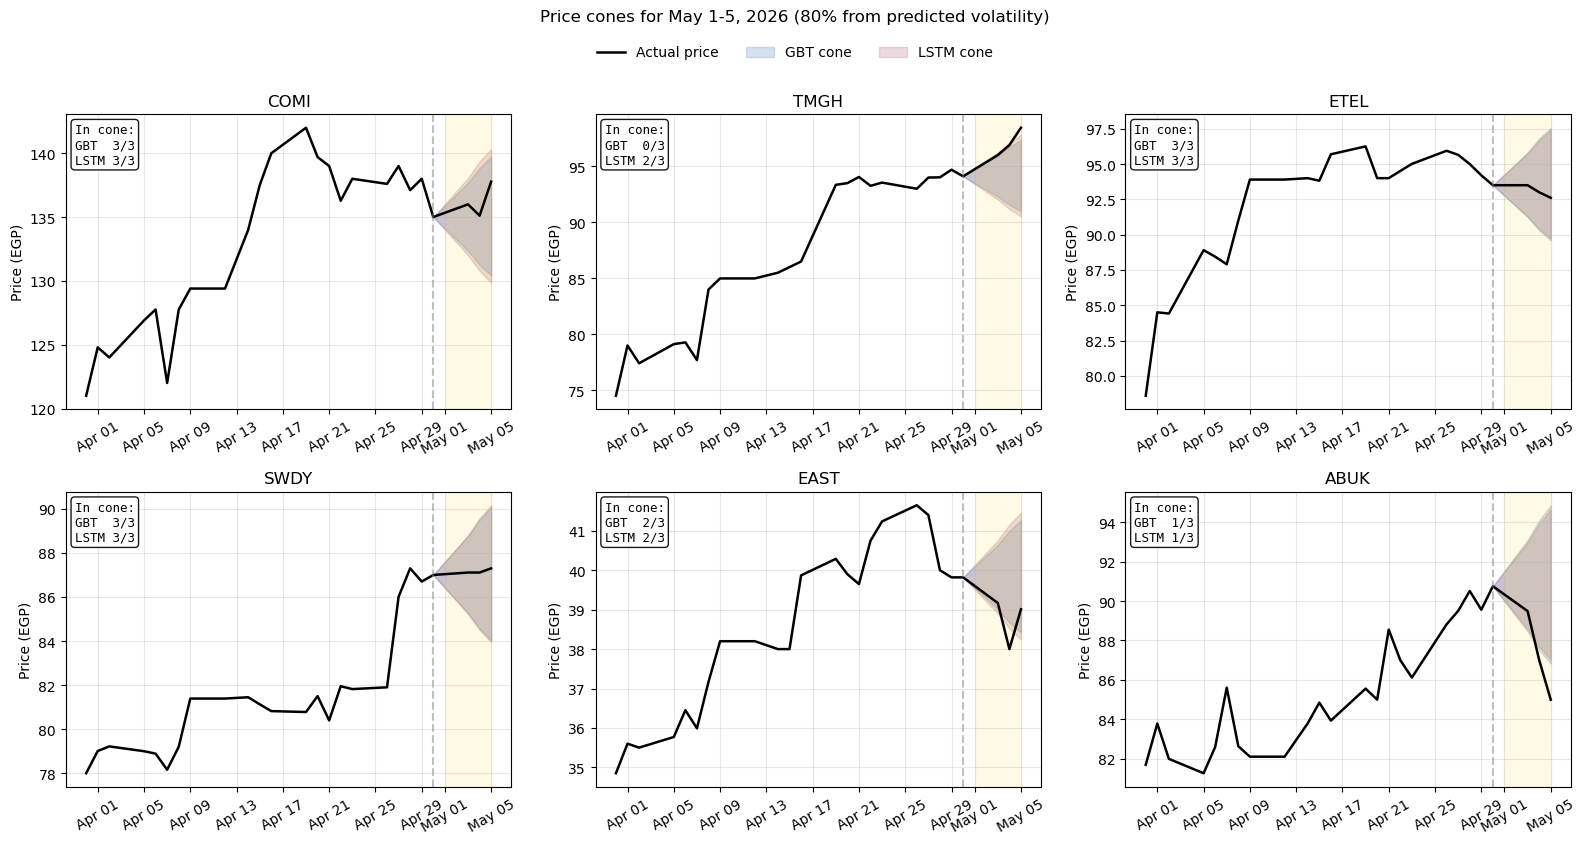

ticker  anchor_price  gbt_sigma  lstm_sigma  gbt_inside  lstm_inside  n_days
  COMI        135.00    0.01552     0.01751           3            3       3
  TMGH         94.11    0.01520     0.01748           0            2       3
  ETEL         93.50    0.01920     0.01856           3            3       3
  SWDY         87.00    0.01568     0.01610           3            3       3
  EAST         39.82    0.01611     0.01824           2            2       3
  ABUK         90.75    0.01994     0.01893           1            1       3


In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False)
axes = axes.flatten()
summary_rows = []

for ax, ticker in zip(axes, DEMO_TICKERS):
    p = prices[prices["ticker"] == ticker].sort_values("date").reset_index(drop=True)
    actual_fw = p[(p["date"] >= FORECAST_START) & (p["date"] <= FORECAST_END)]
    pre = p[p["date"] < FORECAST_START]
    if len(actual_fw) == 0 or len(pre) == 0:
        ax.set_title(f"{ticker}: no data"); ax.axis("off"); continue
    anchor = pre.iloc[-1]
    anchor_date, anchor_price = anchor["date"], anchor["price"]

    preds = combined[(combined["ticker"] == ticker) & (combined["date"] == anchor_date)]
    if len(preds) == 0:
        preds = combined[combined["ticker"] == ticker].assign(diff=lambda d: (d["date"] - anchor_date).abs()).sort_values("diff").head(1)
    if len(preds) == 0:
        ax.set_title(f"{ticker}: no prediction"); ax.axis("off"); continue
    sigma_gbt, sigma_lstm = float(preds["gbt_pred"].iloc[0]), float(preds["lstm_pred"].iloc[0])

    n_proj = len(actual_fw)
    _, gbt_lo, gbt_hi   = project_cone(anchor_price, sigma_gbt,  n_proj)
    _, lstm_lo, lstm_hi = project_cone(anchor_price, sigma_lstm, n_proj)
    forecast_dates = [anchor_date] + list(actual_fw["date"])
    gbt_lo_full = np.concatenate([[anchor_price], gbt_lo])
    gbt_hi_full = np.concatenate([[anchor_price], gbt_hi])
    lstm_lo_full = np.concatenate([[anchor_price], lstm_lo])
    lstm_hi_full = np.concatenate([[anchor_price], lstm_hi])

    history_start = anchor_date - pd.Timedelta(days=HISTORY_DAYS)
    hist = p[(p["date"] >= history_start) & (p["date"] <= FORECAST_END)]
    ax.plot(hist["date"], hist["price"], "k-", linewidth=1.8, label="Actual price")
    ax.fill_between(forecast_dates, gbt_lo_full, gbt_hi_full, color="#185FA5", alpha=0.18, label="GBT cone")
    ax.fill_between(forecast_dates, lstm_lo_full, lstm_hi_full, color="#993556", alpha=0.18, label="LSTM cone")
    ax.axvspan(FORECAST_START, FORECAST_END, color="gold", alpha=0.10)
    ax.axvline(anchor_date, color="gray", linestyle="--", alpha=0.5)

    actual_prices = actual_fw["price"].values
    gbt_inside  = ((actual_prices >= gbt_lo) & (actual_prices <= gbt_hi)).sum()
    lstm_inside = ((actual_prices >= lstm_lo) & (actual_prices <= lstm_hi)).sum()
    badge = f"In cone:\nGBT  {gbt_inside}/{len(actual_prices)}\nLSTM {lstm_inside}/{len(actual_prices)}"
    ax.text(0.02, 0.97, badge, transform=ax.transAxes, fontsize=9, va="top", family="monospace",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))
    summary_rows.append({"ticker": ticker, "anchor_price": round(anchor_price, 3),
                         "gbt_sigma": round(sigma_gbt, 5), "lstm_sigma": round(sigma_lstm, 5),
                         "gbt_inside": gbt_inside, "lstm_inside": lstm_inside,
                         "n_days": len(actual_prices)})
    ax.set_title(f"{ticker}"); ax.set_ylabel("Price (EGP)"); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(axis="x", rotation=30)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.suptitle("Price cones for May 1-5, 2026 (80% from predicted volatility)", y=1.05)
plt.tight_layout()
plt.savefig(f"{LOCAL_FIGS}/fig_price_cones_may2026.png", dpi=150, bbox_inches="tight")
plt.show()

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(f"{LOCAL_RESULTS}/table_price_cone_coverage.csv", index=False)

---
## Direction Prediction with Probability-Shaded Cones

In [28]:
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

clean_for_dir = (spark.read.parquet(HDFS_CLEAN)
                 .filter(F.col("asset_class") == "equity")
                 .select("ticker", "date", "log_return"))
w_fwd_5d = Window.partitionBy("ticker").orderBy("date").rowsBetween(1, 5)
direction_panel = (clean_for_dir
    .withColumn("ret_5d_fwd", F.sum("log_return").over(w_fwd_5d))
    .withColumn("direction_up_5d", (F.col("ret_5d_fwd") > 0).cast("int"))
    .filter(F.col("ret_5d_fwd").isNotNull())
    .select("ticker", "date", "direction_up_5d"))

feats_with_dir = feats.join(direction_panel, on=["ticker", "date"], how="inner")
train_dir = feats_with_dir.filter(F.col("date") <  F.lit(SPLIT_DATE))
test_dir  = feats_with_dir.filter(F.col("date") >= F.lit(SPLIT_DATE))
print(f"Direction train/test: {train_dir.count():,} / {test_dir.count():,}")

Direction train/test: 73,901 / 14,391


In [29]:
# Compute class weights from the TRAINING set only
class_counts = train_dir.groupBy("direction_up_5d").count().collect()
counts = {row["direction_up_5d"]: row["count"] for row in class_counts}
total = sum(counts.values())
n_classes = len(counts)

In [30]:
weights = {cls: total / (n_classes * cnt) for cls, cnt in counts.items()}

print(f"\nClass balance in training set:")
for cls in sorted(counts):
    pct = 100 * counts[cls] / total
    print(f"  direction_up_5d = {cls}:  {counts[cls]:,} rows ({pct:.1f}%)  weight = {weights[cls]:.3f}")

# Attach weight to training data
train_dir_w = train_dir.withColumn(
    "class_weight",
    F.when(F.col("direction_up_5d") == 1, F.lit(weights.get(1, 1.0)))
     .otherwise(F.lit(weights.get(0, 1.0)))
)


Class balance in training set:
  direction_up_5d = 0:  37,489 rows (50.7%)  weight = 0.986
  direction_up_5d = 1:  36,412 rows (49.3%)  weight = 1.015


In [31]:
gbtc = GBTClassifier(
    labelCol="direction_up_5d",
    featuresCol="features",
    weightCol="class_weight",      
    maxIter=100,
    maxDepth=5,
    stepSize=0.1,
    seed=42,
)
pipe_dir = Pipeline(stages=[assembler, gbtc])
t0 = time.time()
dir_model = pipe_dir.fit(train_dir_w)
print(f"  Training time: {time.time()-t0:.1f}s")

  Training time: 18.9s


In [32]:
# Evaluate
pred_dir = dir_model.transform(test_dir)
dir_acc = MulticlassClassificationEvaluator(
    labelCol="direction_up_5d", predictionCol="prediction", metricName="accuracy"
).evaluate(pred_dir)
dir_auc = BinaryClassificationEvaluator(
    labelCol="direction_up_5d", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
).evaluate(pred_dir)
print(f"\nDirection: Accuracy = {dir_acc*100:.2f}%   AUC = {dir_auc:.4f}")




Direction: Accuracy = 51.27%   AUC = 0.5109


In [33]:
from pyspark.sql.types import DoubleType
extract_prob_up = F.udf(lambda v: float(v[1]) if v is not None else None, DoubleType())
dir_test_pdf = (pred_dir
    .withColumn("prob_up", extract_prob_up("probability"))
    .select("ticker", "date", "direction_up_5d", "prob_up").toPandas())
dir_test_pdf["date"] = pd.to_datetime(dir_test_pdf["date"])

bins = [0, 0.3, 0.4, 0.5, 0.6, 0.7, 1.0]
labels = ["<0.30","0.30-0.40","0.40-0.50","0.50-0.60","0.60-0.70",">0.70"]
dir_test_pdf["prob_bin"] = pd.cut(dir_test_pdf["prob_up"], bins=bins, labels=labels, include_lowest=True)
calib = (dir_test_pdf.groupby("prob_bin", observed=True)
         .agg(n=("direction_up_5d", "size"), actual_up_rate=("direction_up_5d", "mean"))
         .reset_index())
print("Direction calibration:")
print(calib.to_string(index=False))
calib.to_csv(f"{LOCAL_RESULTS}/table_direction_calibration.csv", index=False)

Direction calibration:
 prob_bin    n  actual_up_rate
    <0.30  940        0.567021
0.30-0.40 2131        0.511966
0.40-0.50 4297        0.513149
0.50-0.60 4265        0.549355
0.60-0.70 1627        0.590658
    >0.70 1131        0.473033


In [34]:
print("\nConfusion matrix (rows = actual, cols = predicted):")
cm = (pred_dir.groupBy("direction_up_5d", "prediction").count()
      .orderBy("direction_up_5d", "prediction"))
cm.show()

results["Direction Classifier (GBT, 5d)"] = {"accuracy_pct": dir_acc*100, "auc": dir_auc}


Confusion matrix (rows = actual, cols = predicted):
+---------------+----------+-----+
|direction_up_5d|prediction|count|
+---------------+----------+-----+
|              0|       0.0| 3539|
|              0|       1.0| 3184|
|              1|       0.0| 3829|
|              1|       1.0| 3839|
+---------------+----------+-----+



In [35]:
from pyspark.sql.types import DoubleType
extract_prob_up = F.udf(lambda v: float(v[1]) if v is not None else None, DoubleType())
dir_test_pdf = (pred_dir
    .withColumn("prob_up", extract_prob_up("probability"))
    .select("ticker", "date", "direction_up_5d", "prob_up").toPandas())
dir_test_pdf["date"] = pd.to_datetime(dir_test_pdf["date"])

bins = [0, 0.3, 0.4, 0.5, 0.6, 0.7, 1.0]
labels = ["<0.30","0.30-0.40","0.40-0.50","0.50-0.60","0.60-0.70",">0.70"]
dir_test_pdf["prob_bin"] = pd.cut(dir_test_pdf["prob_up"], bins=bins, labels=labels, include_lowest=True)
calib = (dir_test_pdf.groupby("prob_bin", observed=True)
         .agg(n=("direction_up_5d", "size"), actual_up_rate=("direction_up_5d", "mean"))
         .reset_index())
print("Direction calibration:")
print(calib.to_string(index=False))
calib.to_csv(f"{LOCAL_RESULTS}/table_direction_calibration.csv", index=False)

Direction calibration:
 prob_bin    n  actual_up_rate
    <0.30  940        0.567021
0.30-0.40 2131        0.511966
0.40-0.50 4297        0.513149
0.50-0.60 4265        0.549355
0.60-0.70 1627        0.590658
    >0.70 1131        0.473033


---
## Save All Outputs and Extract to Host

In [36]:
# Save trained Spark models to HDFS
print("Saving Spark models to HDFS...")
lr_model.write().overwrite().save(f"{HDFS_RESULTS}/model_lr")
rf_model.write().overwrite().save(f"{HDFS_RESULTS}/model_rf")
gbt_model.write().overwrite().save(f"{HDFS_RESULTS}/model_gbt")
dir_model.write().overwrite().save(f"{HDFS_RESULTS}/model_direction")
print("  Spark models saved to HDFS at /egx/results/")

# Save LSTM weights to LOCAL filesystem
import torch
torch.save(model.state_dict(), f"{LOCAL_RESULTS}/model_lstm.pt")
print(f"  LSTM weights -> {LOCAL_RESULTS}/model_lstm.pt")

# Save final results JSON locally
with open(f"{LOCAL_RESULTS}/results.json", "w") as f:
    json.dump({k: {kk: float(vv) if isinstance(vv, (int, float, np.floating)) else vv
                   for kk, vv in v.items()} for k, v in results.items()}, f, indent=2)
print(f"  results.json -> {LOCAL_RESULTS}/results.json")

print(f"\n{'='*60}")
print("All figures and tables are in the mounted work folder:")
print(f"  Figures: {LOCAL_FIGS}/")
print(f"  Results: {LOCAL_RESULTS}/")
print(f"\nFiles written:")
for d in [LOCAL_FIGS, LOCAL_RESULTS]:
    for fn in sorted(os.listdir(d)):
        path = os.path.join(d, fn)
        if os.path.isfile(path):
            print(f"  {path}  ({os.path.getsize(path)} bytes)")

print(f"\nFinal results summary:")
print(json.dumps(results, indent=2, default=lambda o: float(o) if isinstance(o, np.floating) else str(o)))

Saving Spark models to HDFS...
  Spark models saved to HDFS at /egx/results/
  LSTM weights -> /home/jovyan/work/results/model_lstm.pt
  results.json -> /home/jovyan/work/results/results.json

All figures and tables are in the mounted work folder:
  Figures: /home/jovyan/work/figs/
  Results: /home/jovyan/work/results/

Files written:
  /home/jovyan/work/figs/fig_devaluation_event.png  (151690 bytes)
  /home/jovyan/work/figs/fig_feature_importance.png  (61279 bytes)
  /home/jovyan/work/figs/fig_forecast_may2026.png  (419616 bytes)
  /home/jovyan/work/figs/fig_lstm_training.png  (52217 bytes)
  /home/jovyan/work/figs/fig_price_cones_may2026.png  (259349 bytes)
  /home/jovyan/work/figs/fig_probability_cones_may2026.png  (272286 bytes)
  /home/jovyan/work/figs/fig_sector_rmse.png  (64270 bytes)
  /home/jovyan/work/figs/sanity_target_hist.png  (27027 bytes)
  /home/jovyan/work/figs/sanity_volatility.png  (312372 bytes)
  /home/jovyan/work/results/lstm_test_predictions.csv  (570634 bytes)
 